In [80]:
from pathlib import Path

import sys
# Add src to path for importing local modules
sys.path.insert(0, str(Path("../src").resolve()))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from trompy import save_figure_atomic

from src.outlier_filter import robust_tail_filter_log_area

mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["font.size"] = 8
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams['savefig.transparent'] = True

SAVEFIGS = True

In [81]:
DATAFOLDER = Path("./data")
METAFILE = Path("./data/fenestrations_metafile.xlsx")
FIGSFOLDER = Path("./figs/paper1/panels")

# Ensure output folder exists for direct saves.
FIGSFOLDER.mkdir(parents=True, exist_ok=True)

# save_figure_atomic stages files under _tmp/<relative output path>;
# ensure that staging path exists when using relative figure folders.
(Path.cwd() / "_tmp" / FIGSFOLDER).mkdir(parents=True, exist_ok=True)

data = pd.read_pickle(DATAFOLDER / "roi_data.pickle")

# Extract the DataFrames
rois_df = data['rois']
summary_df = data['summary']

# load metafile
metadata = pd.read_excel(METAFILE)

print("ROI Data Statistics")
print("=" * 50)
print(f"\nROIs DataFrame:")
print(f"  Rows: {len(rois_df)}")
print(f"  Columns: {len(rois_df.columns)}")
print(f"  Column names: {list(rois_df.columns)}")
print(f"\n  Memory usage: {rois_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n\nSummary DataFrame:")
print(f"  Rows: {len(summary_df)}")
print(f"  Columns: {len(summary_df.columns)}")
print(f"  Column names: {list(summary_df.columns)}")
print(f"\n  Memory usage: {summary_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 50)
print("\nFirst few rows of ROIs DataFrame:")
print(rois_df.head())

print("\n" + "=" * 50)
print("\nFirst few rows of Summary DataFrame:")
print(summary_df.head())

print("\n" + "=" * 50)
print("\nData types:")
print("\nROIs DataFrame:")
print(rois_df.dtypes)
print("\nSummary DataFrame:")
print(summary_df.dtypes)

ROI Data Statistics

ROIs DataFrame:
  Rows: 234865
  Columns: 33
  Column names: ['id', 'stub', 'roi_id', 'centroid_x', 'centroid_y', 'pixel_count', 'pixel_size', 'area', 'cluster_neighbor_count', 'cluster_neighbor_ids', 'cluster_max_internal_angle_deg', 'cluster_max_angular_gap_deg', 'cluster_is_convex', 'cluster_center_inside_polygon', 'cluster_is_valid', 'cluster_neighbor_distance', 'profile_major', 'profile_minor', 'profile_diag45', 'profile_diag135', 'four_axis_mean', 'major_axis_angle', 'major_axis_extent', 'minor_axis_extent', 'major_axis_length_px', 'minor_axis_length_px', 'step_major', 'step_minor', 'step_diag45', 'step_diag135', 'diameter_area', 'experiment', 'condition']

  Memory usage: 262.44 MB


Summary DataFrame:
  Rows: 548
  Columns: 20
  Column names: ['id', 'stub', 'mean_neighbor_count', 'mean_cluster_neighbor_distance_px', 'mean_cluster_neighbor_distance_nm', 'mean_roi_area_nm2', 'mean_pixel_size_nm_per_px', 'mean_diameter_area_nm', 'mean_diameter_major_nm', 'mean

In [82]:
def get_filtered_control_data(rois_df, summary_df):
    
    rois_df, _ = robust_tail_filter_log_area(rois_df)
    rois_df = rois_df.query("condition == 'control'").reset_index(drop=True)
    summary_df = summary_df.query("condition == 'control'").reset_index(drop=True)
    
    return rois_df, summary_df

rois_df, summary_df = get_filtered_control_data(rois_df, summary_df)

In [83]:
rois_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59139 entries, 0 to 59138
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              59139 non-null  object 
 1   stub                            59139 non-null  object 
 2   roi_id                          59139 non-null  int64  
 3   centroid_x                      59139 non-null  float64
 4   centroid_y                      59139 non-null  float64
 5   pixel_count                     59139 non-null  int64  
 6   pixel_size                      59139 non-null  float64
 7   area                            59139 non-null  float64
 8   cluster_neighbor_count          45026 non-null  float64
 9   cluster_neighbor_ids            45026 non-null  object 
 10  cluster_max_internal_angle_deg  45026 non-null  float64
 11  cluster_max_angular_gap_deg     45026 non-null  float64
 12  cluster_is_convex               45026 non-n

In [133]:
# setting plotting conventions

def init_diameter_panel():
    f, ax = plt.subplots(figsize=(1.5, 1.2),
                         gridspec_kw={"left": 0.25, "right": 0.95, "top": 0.95, "bottom": 0.35})
    
    return f, ax

diameter_color = "steelblue"
circularity_color = "coral"
minor_color = "seagreen"
major_color = "mediumpurple"

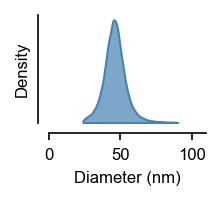

In [134]:
## Panel A: Diameter distribution (circular)

xlims = (0, 110)

f, ax = init_diameter_panel()
sns.kdeplot(data=rois_df.diameter_area,
            fill=True, ax=ax, color="steelblue", alpha=0.7,
            cut=0)

ax.set_xlim(xlims)
ax.set_xlabel("Diameter (nm)")

ax.set_yticks([])

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "diameter_circular")

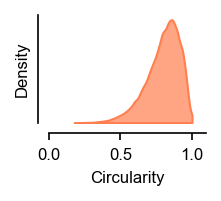

In [135]:
## Panel B: Circularity distribution

rois_df["circularity"] = rois_df.minor_axis_length_px / rois_df.major_axis_length_px


f, ax = init_diameter_panel()
sns.kdeplot(data=rois_df.circularity,
            fill=True, ax=ax, color=circularity_color, alpha=0.7,
            cut=0)
ax.set_xlabel("Circularity")
ax.set_xlim(0, 1.1)
ax.set_yticks([])

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "circularity")

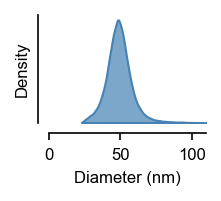

In [136]:
## Panel C: Diameter distribution (elliptical)

# Figure for diameter based on major/minor axis
# Calculate equivalent diameter in px
rois_df['elliptical_diameter'] = np.sqrt(rois_df.major_axis_length_px * rois_df.minor_axis_length_px) 

f, ax = init_diameter_panel()
sns.kdeplot(data=rois_df.elliptical_diameter,
            fill=True, ax=ax, color="steelblue", alpha=0.7,
            cut=0)

ax.set_xlabel("Diameter (nm)")
ax.set_xlim(xlims)
ax.set_yticks([])

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "diameter_elliptical")


In [137]:
def get_spacing_factor(rois_df, row, axis):
    
    if axis == "major":
        return (rois_df
                .query("stub == @row.stub")
                .step_major_nm
                .mean()
                )
    elif axis == "minor":
        return (rois_df
                .query("stub == @row.stub")
                .step_minor_nm
                .mean()
                )
    else:
        raise ValueError("Axis must be 'major' or 'minor'")

# per-ROI nm per sample
rois_df["step_major_nm"] = rois_df["step_major"] * rois_df["pixel_size"]
rois_df["step_minor_nm"] = rois_df["step_minor"] * rois_df["pixel_size"]

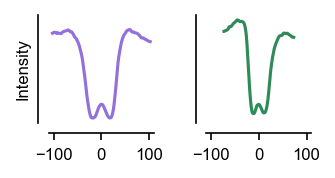

In [145]:
# prep data for profiles plot
row = summary_df.iloc[0]

f, ax = plt.subplots(figsize=(2.5, 1.2), ncols=2, sharey=True,
                         gridspec_kw={"left": 0.25, "right": 0.95, "top": 0.95, "bottom": 0.35,
                                      "wspace": 0.5})

major_profile = row.mean_profile_major_smpls
n = len(major_profile)
x_nm = (np.arange(n) - (n - 1) / 2) * get_spacing_factor(rois_df, row, "major")

ax[0].plot(x_nm, major_profile, color=major_color)
ax[0].set_ylabel("Intensity")
ax[0].set_yticks([])

minor_profile = row.mean_profile_minor_smpls
n = len(minor_profile)
x_nm = (np.arange(n) - (n - 1) / 2) * get_spacing_factor(rois_df, row, "minor")

ax[1].plot(x_nm, minor_profile, color=minor_color)

for axis in ax:
    axis.set_xlim(-110, 110)
    sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "profiles")

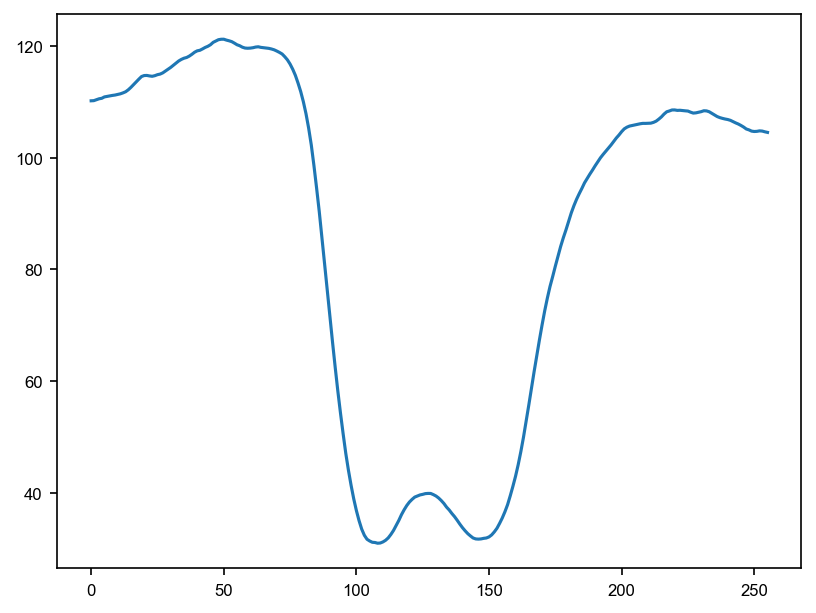

In [108]:
summary_df.columns

Index(['id', 'stub', 'mean_neighbor_count',
       'mean_cluster_neighbor_distance_px',
       'mean_cluster_neighbor_distance_nm', 'mean_roi_area_nm2',
       'mean_pixel_size_nm_per_px', 'mean_diameter_area_nm',
       'mean_diameter_major_nm', 'mean_diameter_minor_nm',
       'mean_diameter_four_axis_nm', 'mean_profile_major_smpls',
       'mean_profile_minor_smpls', 'mean_four_axis_smpls', 'porosity_square',
       'porosity_hex', 'porosity_blend', 'blend_weight', 'experiment',
       'condition'],
      dtype='object')

In [109]:
rois_df.columns

Index(['id', 'stub', 'roi_id', 'centroid_x', 'centroid_y', 'pixel_count',
       'pixel_size', 'area', 'cluster_neighbor_count', 'cluster_neighbor_ids',
       'cluster_max_internal_angle_deg', 'cluster_max_angular_gap_deg',
       'cluster_is_convex', 'cluster_center_inside_polygon',
       'cluster_is_valid', 'cluster_neighbor_distance', 'profile_major',
       'profile_minor', 'profile_diag45', 'profile_diag135', 'four_axis_mean',
       'major_axis_angle', 'major_axis_extent', 'minor_axis_extent',
       'major_axis_length_px', 'minor_axis_length_px', 'step_major',
       'step_minor', 'step_diag45', 'step_diag135', 'diameter_area',
       'experiment', 'condition', 'robust_z_log_area', 'circularity',
       'elliptical_diameter'],
      dtype='object')

In [125]:
rois_df.iloc[0].step_major * rois_df.iloc[0].pixel_size 

np.float64(0.5380925430790416)

In [ ]:
rois_df.step_major